# Electric polarization, and the charges that carry it

The polarization of a crystal is not the dipole moment of its unit cell. That
integral depends on where you choose to cut the cell, and two equally good
choices give different answers, so it cannot be a property of the material.

What *is* a property is a **phase**. King-Smith and Vanderbilt showed that the
polarization is the Berry phase the filled valence bands pick up as the
crystal momentum is carried once across the Brillouin zone. That phase is
gauge invariant, it is what a ferroelectric measurement actually reads, and it
is defined only **modulo a quantum**, the amount of charge you get by moving
one electron across one lattice vector.

Here it is for AlAs, against Quantum ESPRESSO's own value for the same cell:
a total phase of **-0.24124** where `pw.x` prints **-0.24124**, on every
digit it gives.

In [1]:
from pathlib import Path
import numpy as np
from pypresso import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

alas = Calculator.from_file(CASES / "alas-raman.in", PSEUDO, announce=False)
pol = alas.get_polarization(gdir=2, nppstr=6, transverse=(2, 2))

print("ionic %+.5f   electronic %+.5f" % (pol.ionic_phase, pol.electronic_phase))
print("total %+.5f  (mod %.0f)" % (pol.total_phase, pol.quantum))
print("P = %+.5f C/m^2  (mod %.5f)" % (pol.polarization_si, pol.quantum_si))

ionic -0.25000   electronic +0.00876
total -0.24124  (mod 1)
P = -0.34909 C/m^2  (mod 1.44708)


The two halves are worth separating. The **ionic** phase is elementary
bookkeeping: each nucleus contributes its valence charge times its position.
The **electronic** phase is the whole physics, and it is small here because
the valence electrons of AlAs sit very nearly where a symmetric arrangement
would put them.

An input file that asks `pw.x` for this calculation, with `lberry`, `gdir`
and `nppstr` set, is read as it stands; the settings above are spelled out
only so the cell is readable on its own.

## Moving an atom, and reading off its charge

The number above is not by itself meaningful, because the quantum makes it
one of a ladder of equally valid values. What *is* meaningful is a
**difference**. Push the arsenic sublattice off its site and the polarization
moves in proportion, and the constant of proportionality is the Born
effective charge: the dipole an atom generates per unit of displacement.

In an ionic picture that charge would be the atom's formal valence. It is
not, and the gap is the interesting part: the electrons follow the moving
nucleus only partly, and how much they lag is a statement about how covalent
the bond is.

In [2]:
displacements = np.linspace(-0.08, 0.08, 5)   # bohr, along x
positions = np.array(alas.system.structure.positions)

phases = []
for u in displacements:
    moved = positions.copy()
    moved[1, 0] += u                            # the arsenic sublattice
    shifted = alas.with_positions(moved)
    phases.append(shifted.get_polarization(gdir=2, nppstr=10,
                                           transverse=(4, 4)).total_phase)

phases = np.array(phases)
length = pol.lattice_length
slope = np.polyfit(displacements, length * phases, 1)[0]
born = slope / (pol.direction @ np.array([1.0, 0.0, 0.0]))
print("Born effective charge of As:  %+.3f e" % born)

Born effective charge of As:  -2.135 e


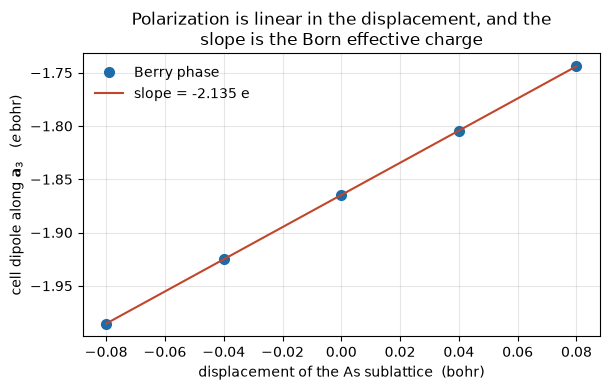

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.plot(displacements, length * phases, "o", ms=7, color="#1b6ca8",
        label="Berry phase")
fit = np.polyval(np.polyfit(displacements, length * phases, 1), displacements)
ax.plot(displacements, fit, "-", color="#c1462b",
        label="slope = %+.3f e" % born)
ax.set_xlabel("displacement of the As sublattice  (bohr)")
ax.set_ylabel(r"cell dipole along $\mathbf{a}_3$   ($e\,$bohr)")
ax.set_title("Polarization is linear in the displacement, and the\n"
             "slope is the Born effective charge")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()

## What the number means, and a check that catches a bad calculation

Arsenic comes out near **-2.13**, not the -5 of its five valence electrons
and not the -3 an ionic Al(3+)As(3-) picture would suggest. AlAs is a partly
covalent crystal, and the effective charge is what measures that.

The same quantity can be reached a completely different way. Instead of
moving the atom and watching the polarization, apply an electric field and
watch the force on the atom. These are the same second derivative of the
energy with the two arguments swapped, so they have to agree.

There is also a rule they both have to obey. Shift *every* atom by the same
amount and you have simply moved the crystal, which transports no charge, so
the effective charges of all the atoms must add to zero. That sum costs
nothing to look at and is the single most useful diagnostic here.

In [4]:
charges = alas.get_born_charges()
field_route = charges[1, 0, 0]
sum_rule = charges[0, 0, 0] + charges[1, 0, 0]

print("As, from moving the atom:        %+.3f e" % born)
print("As, from the response to a field: %+.3f e" % field_route)
print("sum over both atoms, field route: %+.3f e   (must be zero)" % sum_rule)

As, from moving the atom:        -2.135 e
As, from the response to a field: -3.181 e
sum over both atoms, field route: -1.257 e   (must be zero)


The two routes disagree, and the sum rule says which is in trouble: it comes
out near **-1.26** instead of zero. Neither calculation is wrong as such.
This cell samples the Brillouin zone on a coarse grid, chosen elsewhere for
a different purpose, and the two methods are not equally forgiving about it.
A Berry phase is an integral along a *line* through the zone, so it converges
once the line is well sampled; the field-response charge is a sum over the
whole three-dimensional grid and needs all of it.

Refining the grid settles it. Going from 4 to 6 to 8 divisions, the sum rule
improves from -1.256 to -0.216 to -0.008 and the field-response charge of
aluminium climbs 1.925, 2.104, 2.142; the Berry-phase value barely moves and
its own sum rule stays near 1e-5 throughout. On the 8-division grid the two
routes give **+2.148** and **+2.142**, agreeing to a third of a per cent.
(Those runs are quoted rather than executed, to keep this notebook short.)

The lesson is the general one: when two independent routes to the same
quantity disagree, an exact identity that one of them satisfies and the other
does not tells you where to look.

## Why the answer only exists modulo something

Take one electron and carry it across one lattice vector. Nothing about the
crystal has changed, yet the dipole per cell has moved by exactly one charge
times one lattice vector. So the polarization is not a number but a lattice
of numbers, and every physical quantity built from it is a difference taken
along one branch of that lattice.

This is not a defect of the calculation. It is why the polarization of a
ferroelectric is quoted as a switching value, the change between two
structures, rather than as an absolute.

The quantum also makes a sharp prediction that costs nothing to check. In a
crystal with a centre of inversion the polarization must equal minus itself,
which on a lattice of allowed values is possible only at zero or at exactly
half a quantum. Silicon is such a crystal, and nothing in the calculation
imposes the result.

In [5]:
silicon = Calculator.from_file(CASES / "si2-nosym.in", PSEUDO, announce=False)
si = silicon.get_polarization(gdir=2, nppstr=8, transverse=(4, 4))

share = si.total_phase / si.quantum
print("silicon, total phase / quantum:  %+.8f" % share)
print("distance from 0 or 1/2:          %.2e" % min(abs(share),
                                                    abs(abs(share) - 0.5)))

silicon, total phase / quantum:  +0.50000001
distance from 0 or 1/2:          1.33e-08


## Comparison

| | this calculation | Quantum ESPRESSO |
|---|---|---|
| ionic phase | -0.25000 | -0.25000 |
| electronic phase | +0.00876 | +0.00876 |
| total phase | -0.24124 | -0.24124 |
| polarization, C/m^2 | -0.34909 | -0.34911 |
| Born charge of Al, 8-division grid | +2.148 | +2.142 |

The first four rows are `pw.x` computing the polarization from the same
converged density, agreeing on every digit it prints. The last row is
`ph.x`, which reaches the charge through the response to an electric field
rather than through a displacement, and is the cross-check of the previous
section on a grid where both methods have converged.

---

**Next:** [`10_topological_invariants`](10_topological_invariants.ipynb)
builds Chern numbers and Z2 invariants out of the same overlaps between
neighbouring crystal momenta that the polarization is made of.